In [1]:
# 기본
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 경고 뜨지 않게 설정
import warnings
warnings.filterwarnings('ignore')

# 그래프 설정
sns.set()

# 그래프 기본 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
# plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['figure.figsize'] = 12, 6
plt.rcParams['font.size'] = 14
plt.rcParams['axes.unicode_minus'] = False

# 결측치 시각화를 위한 라이브러리
import missingno

# 데이터 전처리 알고리즘
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# 학습 모델 저장을 위한 라이브러리
import pickle

# 다중공선성 확인을 위햔 라이브러리
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# 기타 라이브러리
from scipy.stats import skew
from scipy.stats import norm

In [21]:
train_df = pd.read_parquet("C:/Users/이민정/Desktop/부트캠프/파이널프로젝트/전처리/AB추출.parquet")

- train_df에 선정된 기준 : 상관계수 0.3이상 확인 후 다중공선성 확인하여 가장 높은것 하나씩 제거해가면서 5미만으로 될때까지 계산

In [104]:
train_df = train_df[['카드이용한도금액','CA한도금액',
         '이용건수_선결제_R3M',
        '선입금원금_B2M','상환개월수_결제일_R3M',
        '선입금원금_B5M','이용개월수_결제일_R6M']]

train_df

,카드이용한도금액,CA한도금액,이용건수_선결제_R3M,선입금원금_B2M,상환개월수_결제일_R3M,선입금원금_B5M,이용개월수_결제일_R6M
0,207389,57536,0,0,3,0,6
1,197758,53971,0,0,3,0,6
2,197683,53533,0,0,3,0,6
3,206550,57970,0,0,3,0,6
4,197457,60800,42,7539,2,0,5
...,...,...,...,...,...,...,...
1111,221217,0,0,0,3,0,6
1112,186656,52255,0,5617,2,5913,6
1113,56668,19216,0,0,1,8254,3
1114,191082,59353,0,0,3,0,6


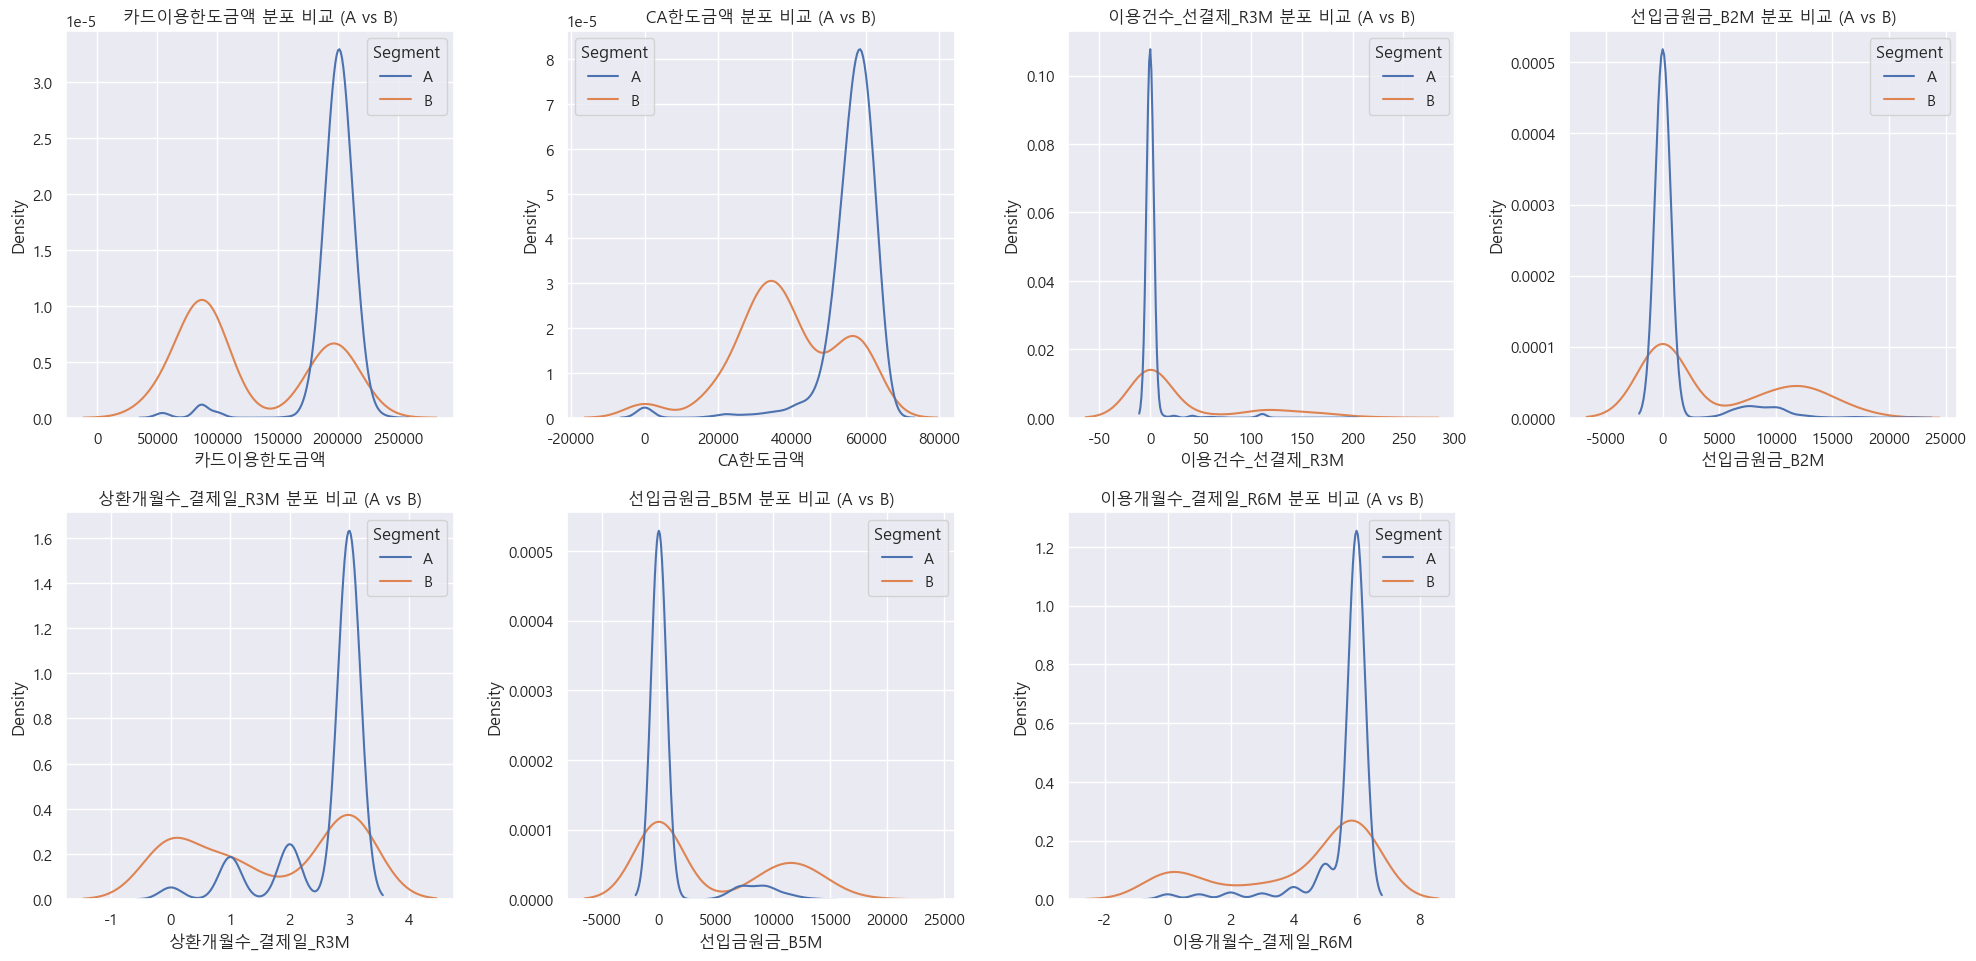

In [51]:
features = ['카드이용한도금액','CA한도금액',
            '이용건수_선결제_R3M','선입금원금_B2M',
            '상환개월수_결제일_R3M','선입금원금_B5M','이용개월수_결제일_R6M']

plt.figure(figsize=(20, 10))

for i, f in enumerate(features):
    plt.subplot(2, 4, i+1)
    sns.kdeplot(data=df, x=f, hue='Segment', common_norm=False)
    plt.title(f'{f} 분포 비교 (A vs B)')


plt.subplot(2, 4, 8).axis('off')

plt.tight_layout()
plt.show()

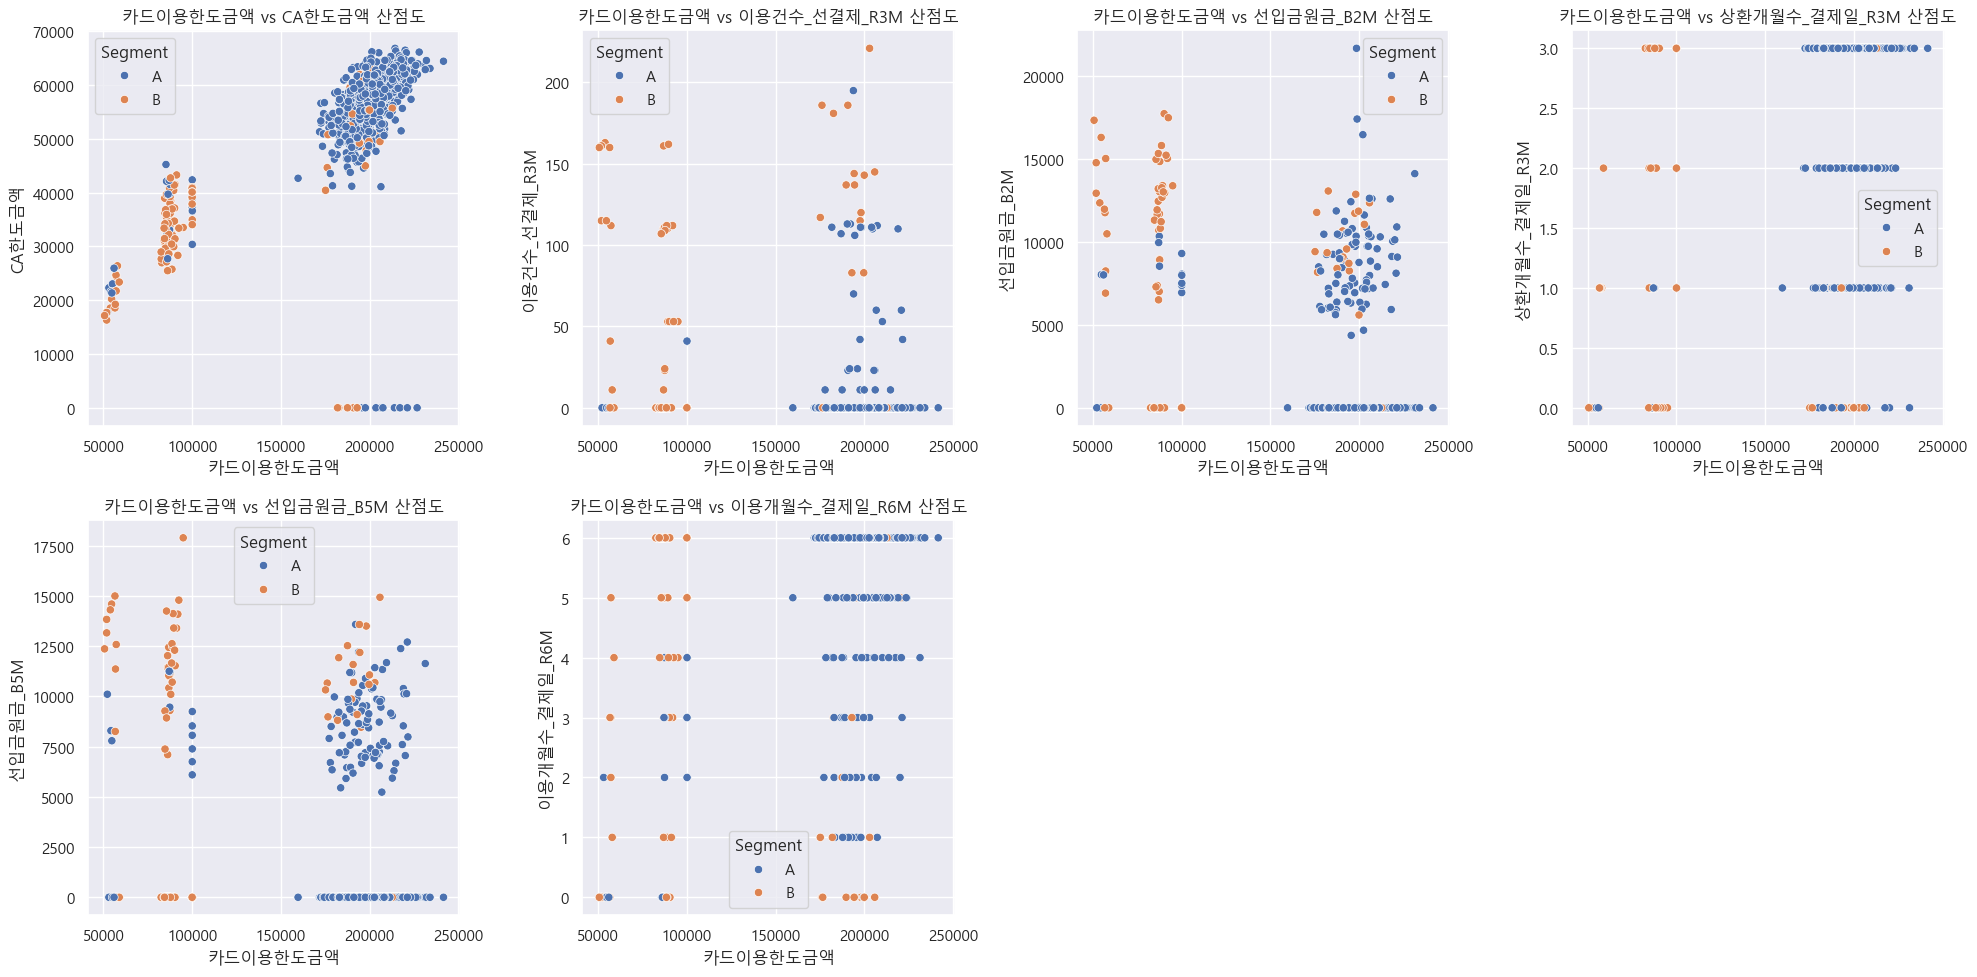

In [81]:
features = ['CA한도금액', '이용건수_선결제_R3M', '선입금원금_B2M',
            '상환개월수_결제일_R3M', '선입금원금_B5M', '이용개월수_결제일_R6M']

plt.figure(figsize=(20, 10))

for i, f in enumerate(features):
    plt.subplot(2, 4, i+1)
    sns.scatterplot(data=df, x='카드이용한도금액', y=f, hue='Segment')
    plt.title(f'카드이용한도금액 vs {f} 산점도')

plt.subplot(2, 4, 7+1).axis('off')

plt.tight_layout()
plt.show()

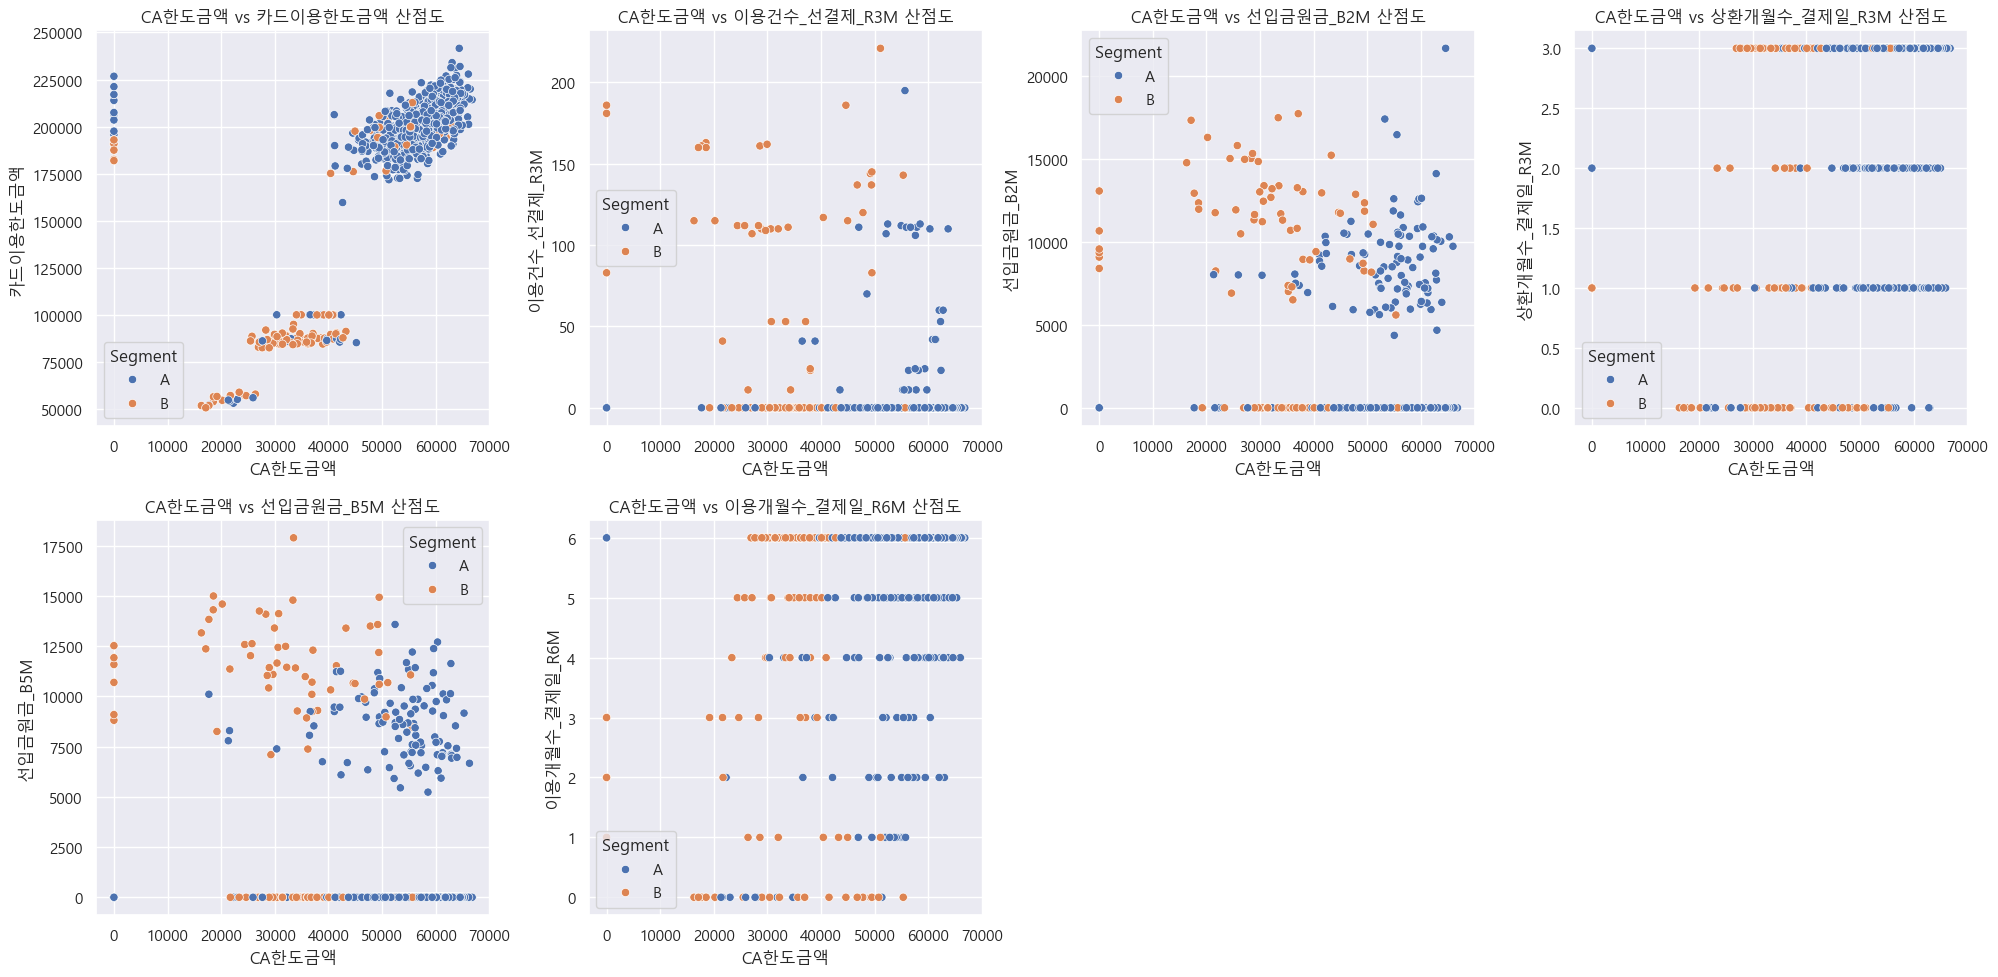

In [91]:
features = ['카드이용한도금액', '이용건수_선결제_R3M', '선입금원금_B2M',
            '상환개월수_결제일_R3M', '선입금원금_B5M', '이용개월수_결제일_R6M']

plt.figure(figsize=(20, 10))

for i, f in enumerate(features):
    plt.subplot(2, 4, i+1)
    sns.scatterplot(data=df, x='CA한도금액', y=f, hue='Segment')
    plt.title(f'CA한도금액 vs {f} 산점도')

plt.subplot(2, 4, 7+1).axis('off')

plt.tight_layout()
plt.show()

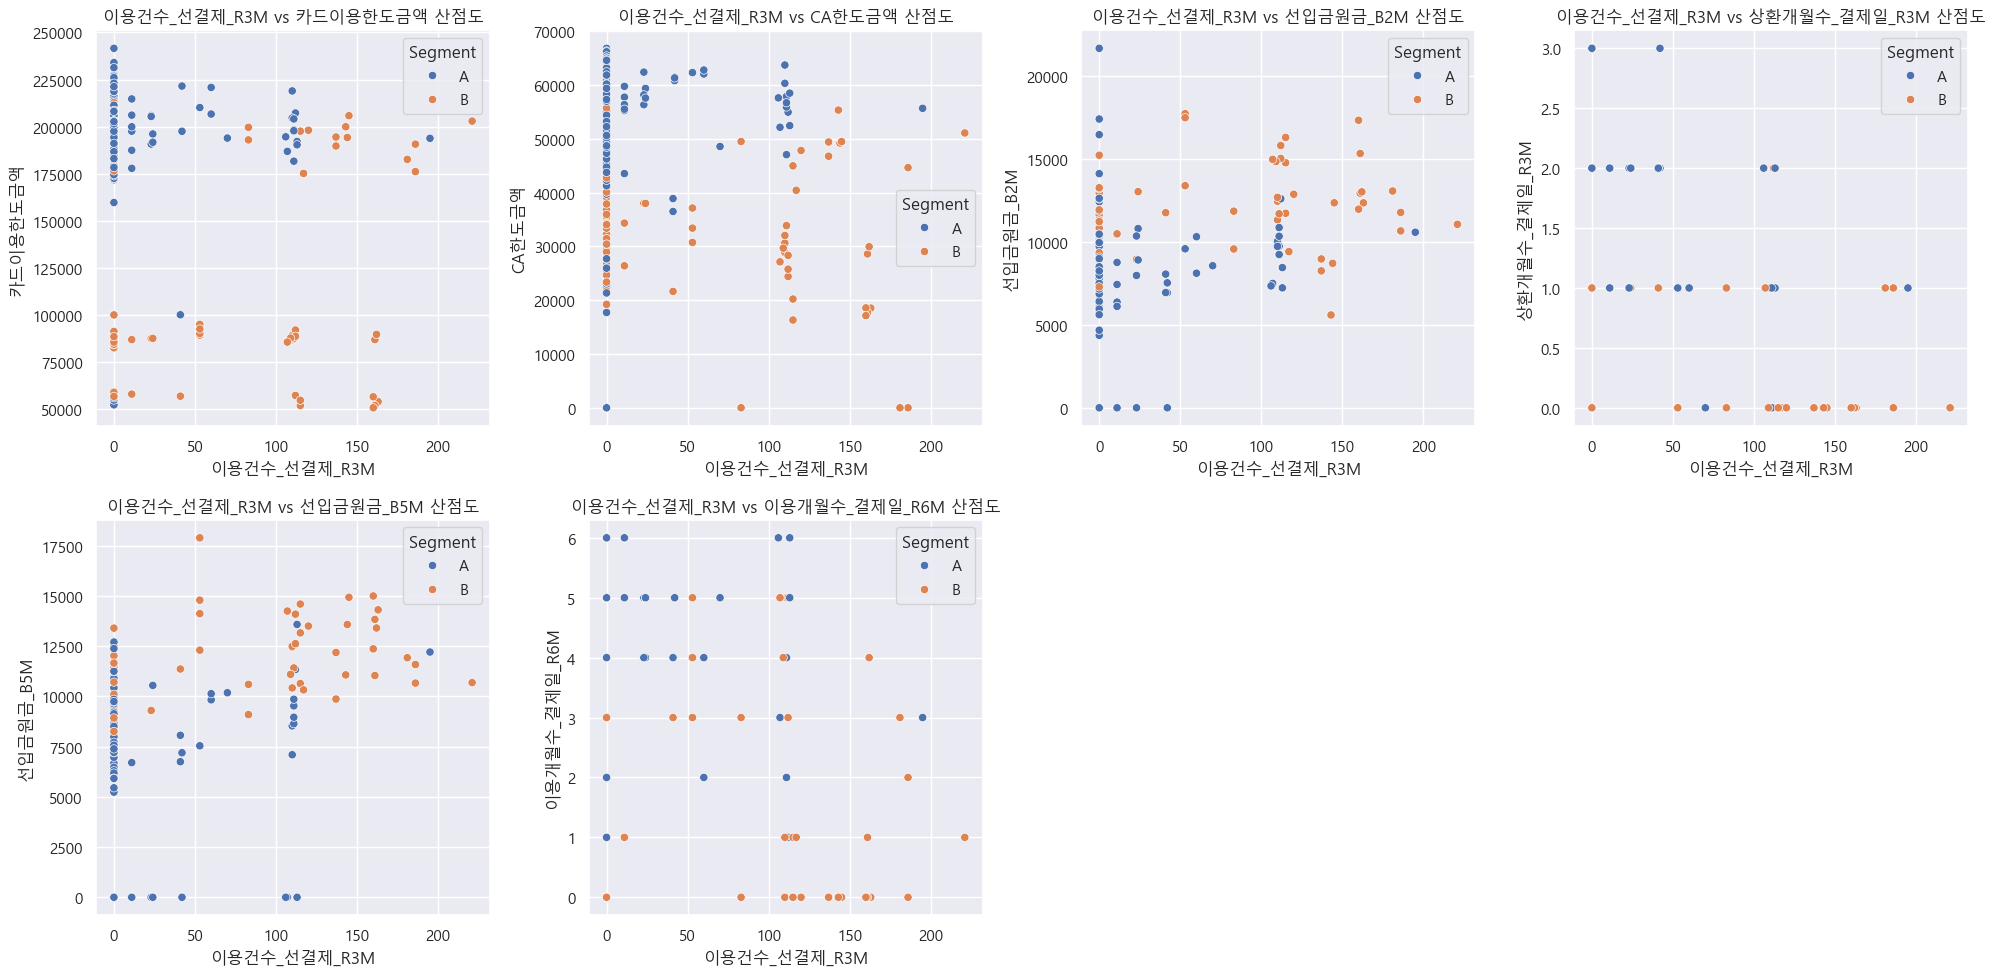

In [93]:
features = ['카드이용한도금액','CA한도금액', '선입금원금_B2M',
            '상환개월수_결제일_R3M', '선입금원금_B5M', '이용개월수_결제일_R6M']

plt.figure(figsize=(20, 10))

for i, f in enumerate(features):
    plt.subplot(2, 4, i+1)
    sns.scatterplot(data=df, x='이용건수_선결제_R3M', y=f, hue='Segment')
    plt.title(f'이용건수_선결제_R3M vs {f} 산점도')

plt.subplot(2, 4, 7+1).axis('off')

plt.tight_layout()
plt.show()

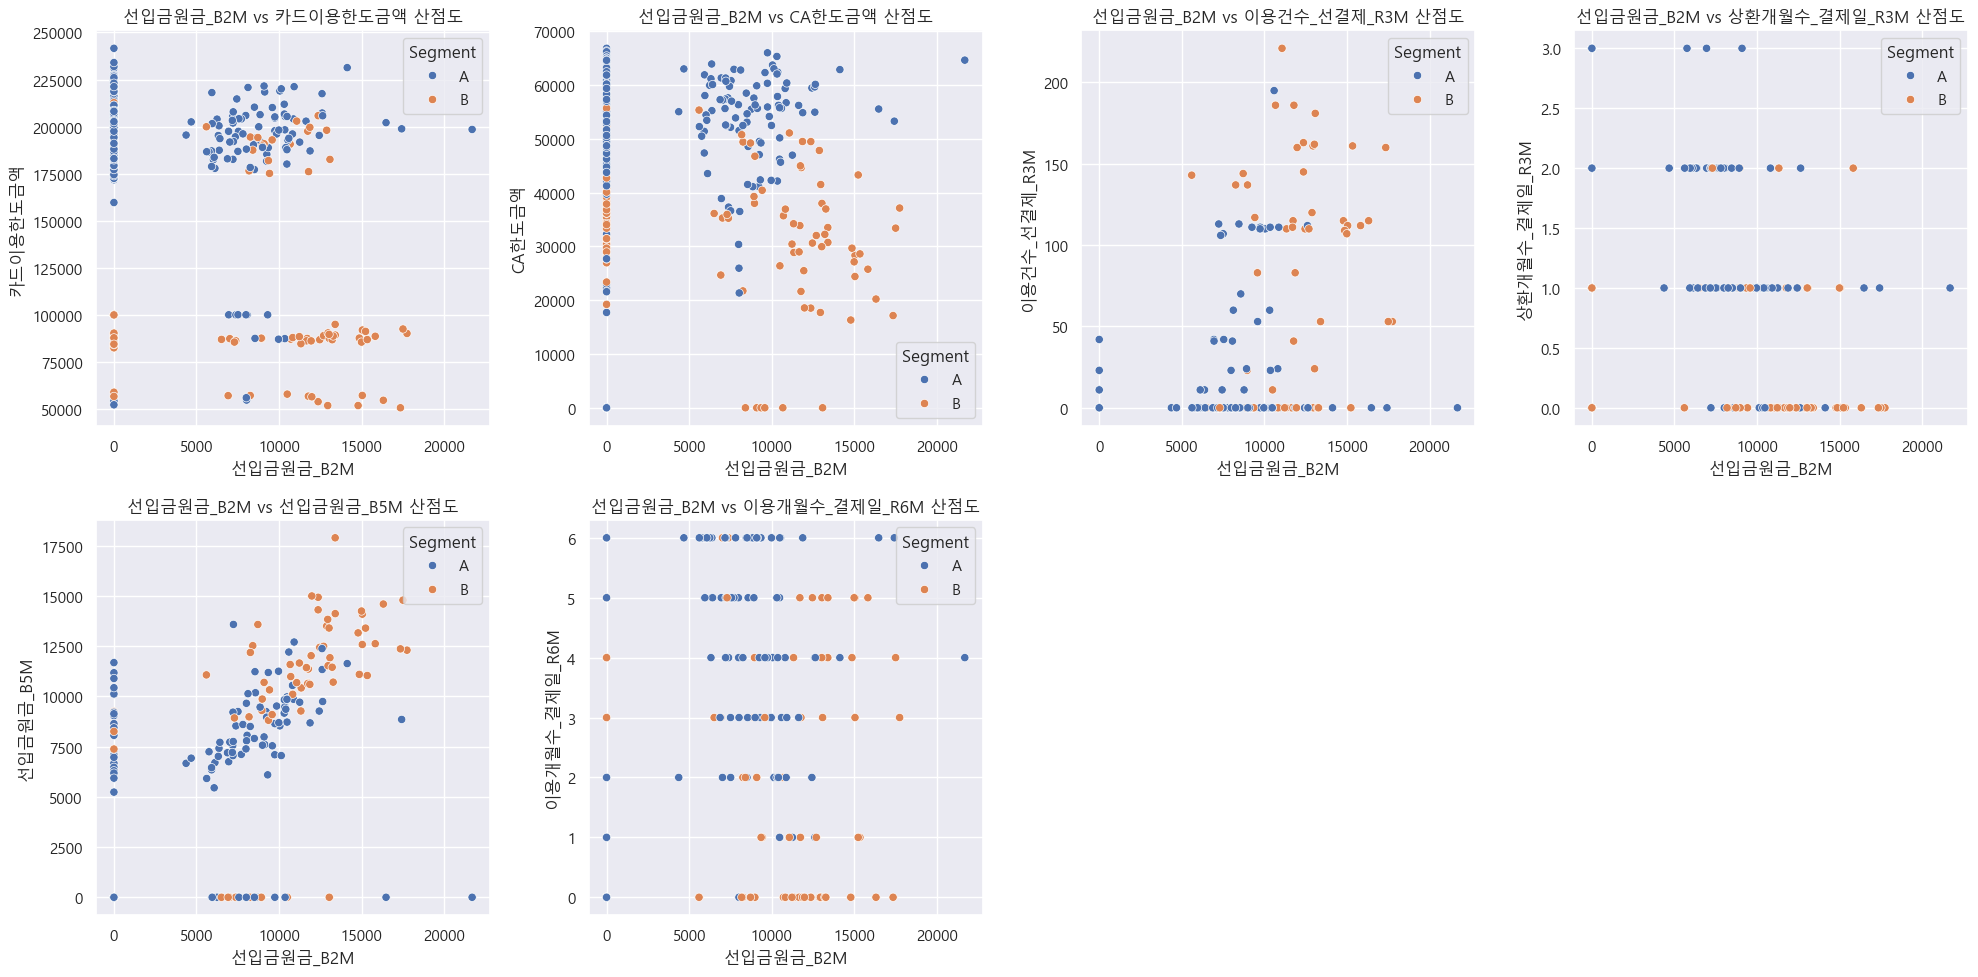

In [95]:
features = ['카드이용한도금액','CA한도금액', '이용건수_선결제_R3M',
            '상환개월수_결제일_R3M', '선입금원금_B5M', '이용개월수_결제일_R6M']

plt.figure(figsize=(20, 10))

for i, f in enumerate(features):
    plt.subplot(2, 4, i+1)
    sns.scatterplot(data=df, x='선입금원금_B2M', y=f, hue='Segment')
    plt.title(f'선입금원금_B2M vs {f} 산점도')

plt.subplot(2, 4, 7+1).axis('off')

plt.tight_layout()
plt.show()

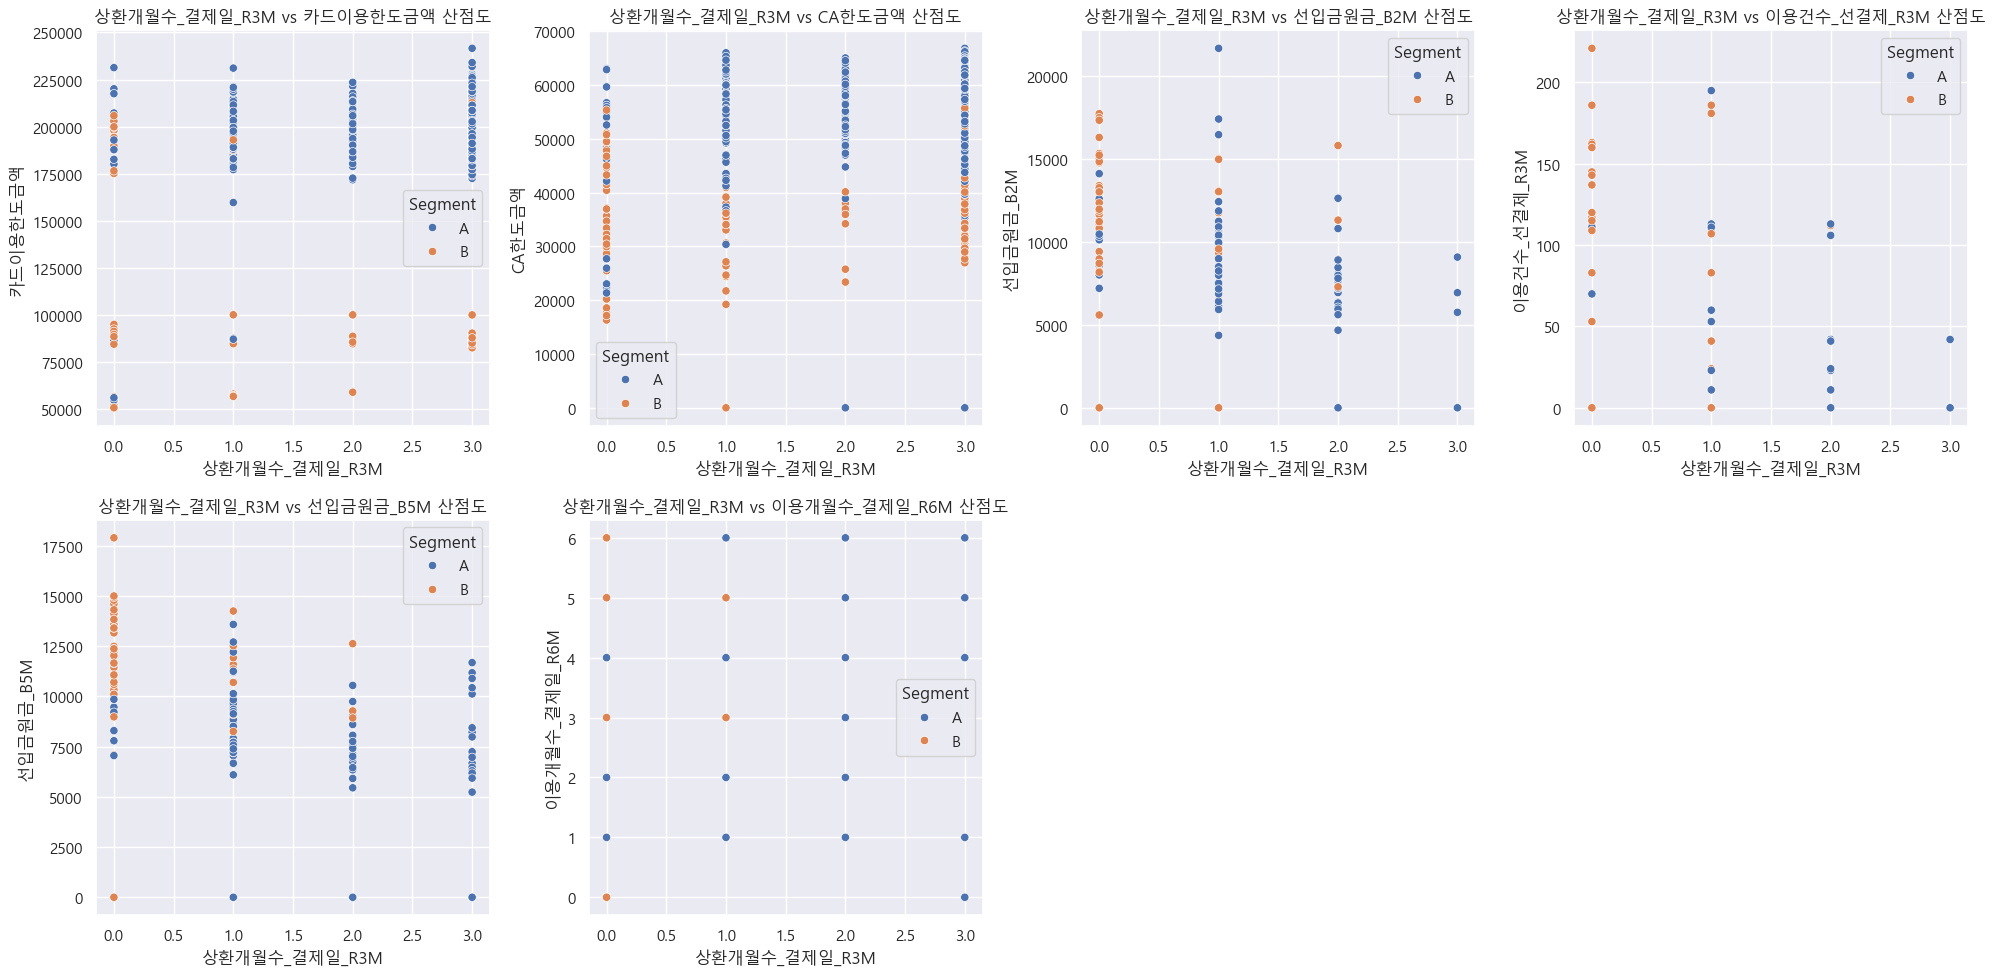

In [97]:
features = ['카드이용한도금액','CA한도금액', '선입금원금_B2M',
            '이용건수_선결제_R3M', '선입금원금_B5M', '이용개월수_결제일_R6M']

plt.figure(figsize=(20, 10))

for i, f in enumerate(features):
    plt.subplot(2, 4, i+1)
    sns.scatterplot(data=df, x='상환개월수_결제일_R3M', y=f, hue='Segment')
    plt.title(f'상환개월수_결제일_R3M vs {f} 산점도')

plt.subplot(2, 4, 7+1).axis('off')

plt.tight_layout()
plt.show()

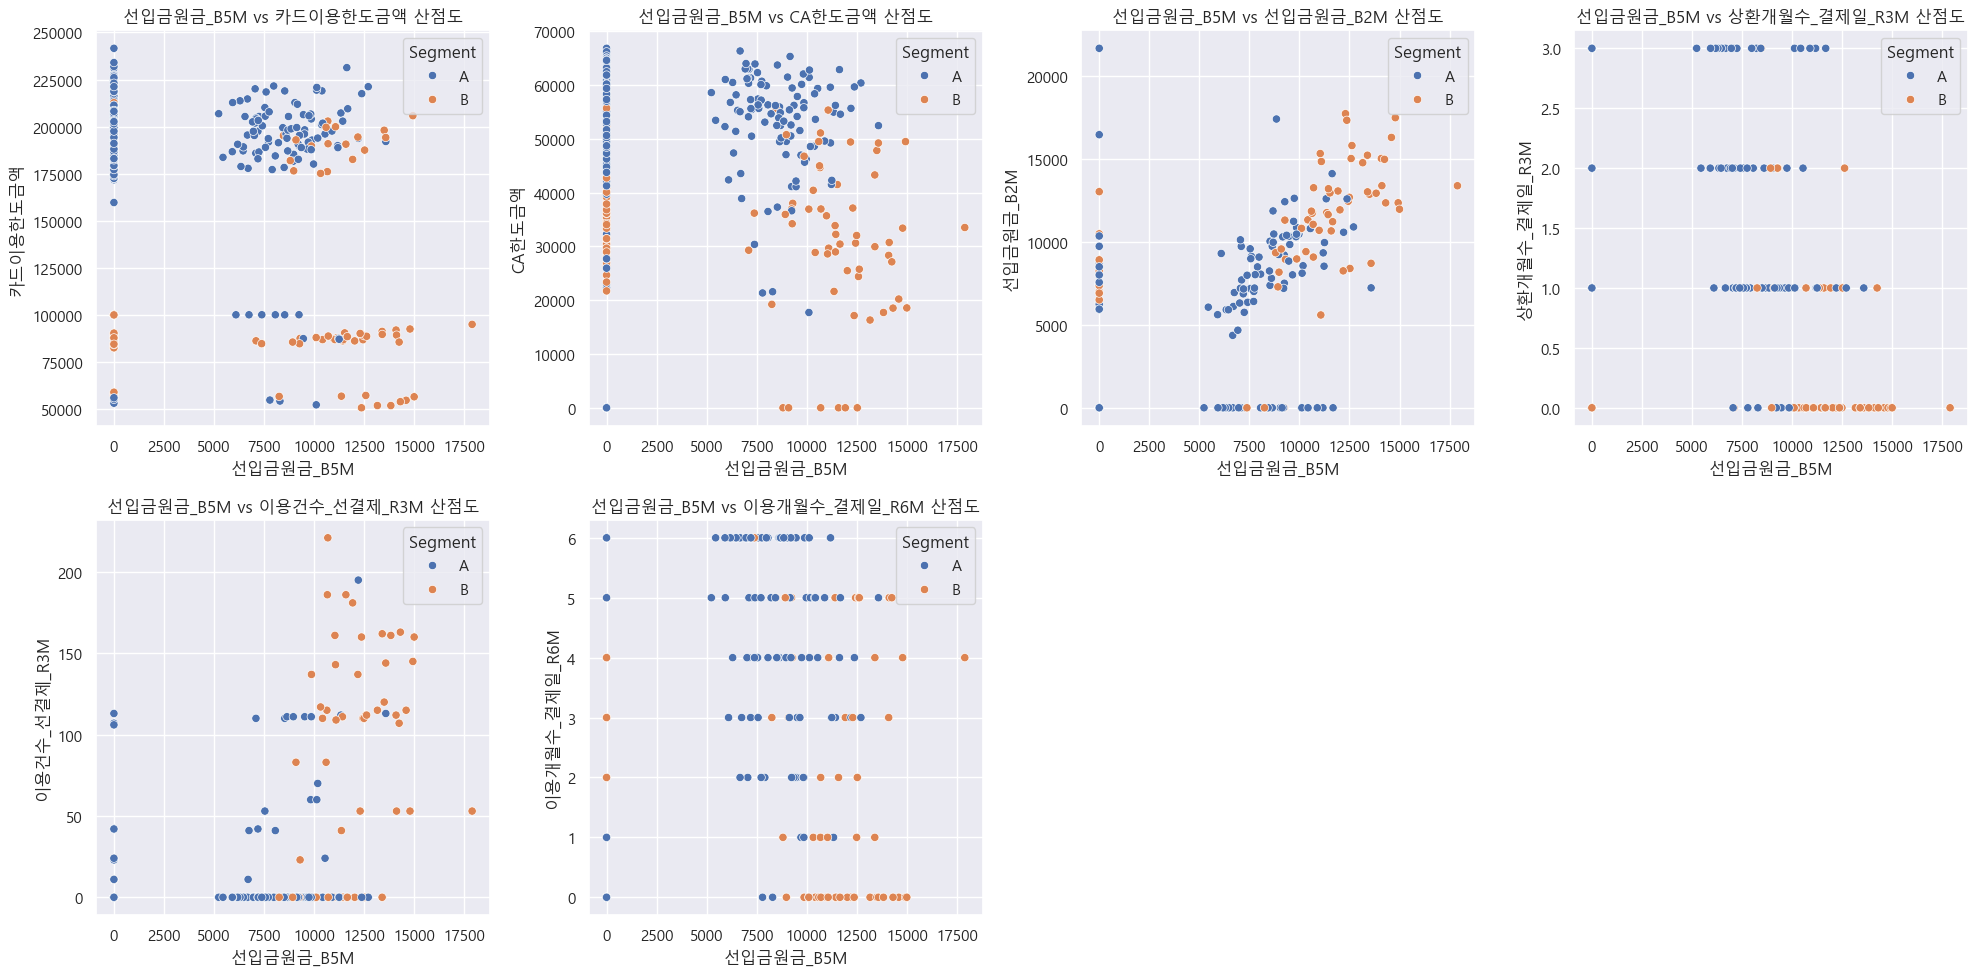

In [99]:
features = ['카드이용한도금액','CA한도금액', '선입금원금_B2M',
            '상환개월수_결제일_R3M', '이용건수_선결제_R3M', '이용개월수_결제일_R6M']

plt.figure(figsize=(20, 10))

for i, f in enumerate(features):
    plt.subplot(2, 4, i+1)
    sns.scatterplot(data=df, x='선입금원금_B5M', y=f, hue='Segment')
    plt.title(f'선입금원금_B5M vs {f} 산점도')

plt.subplot(2, 4, 7+1).axis('off')

plt.tight_layout()
plt.show()

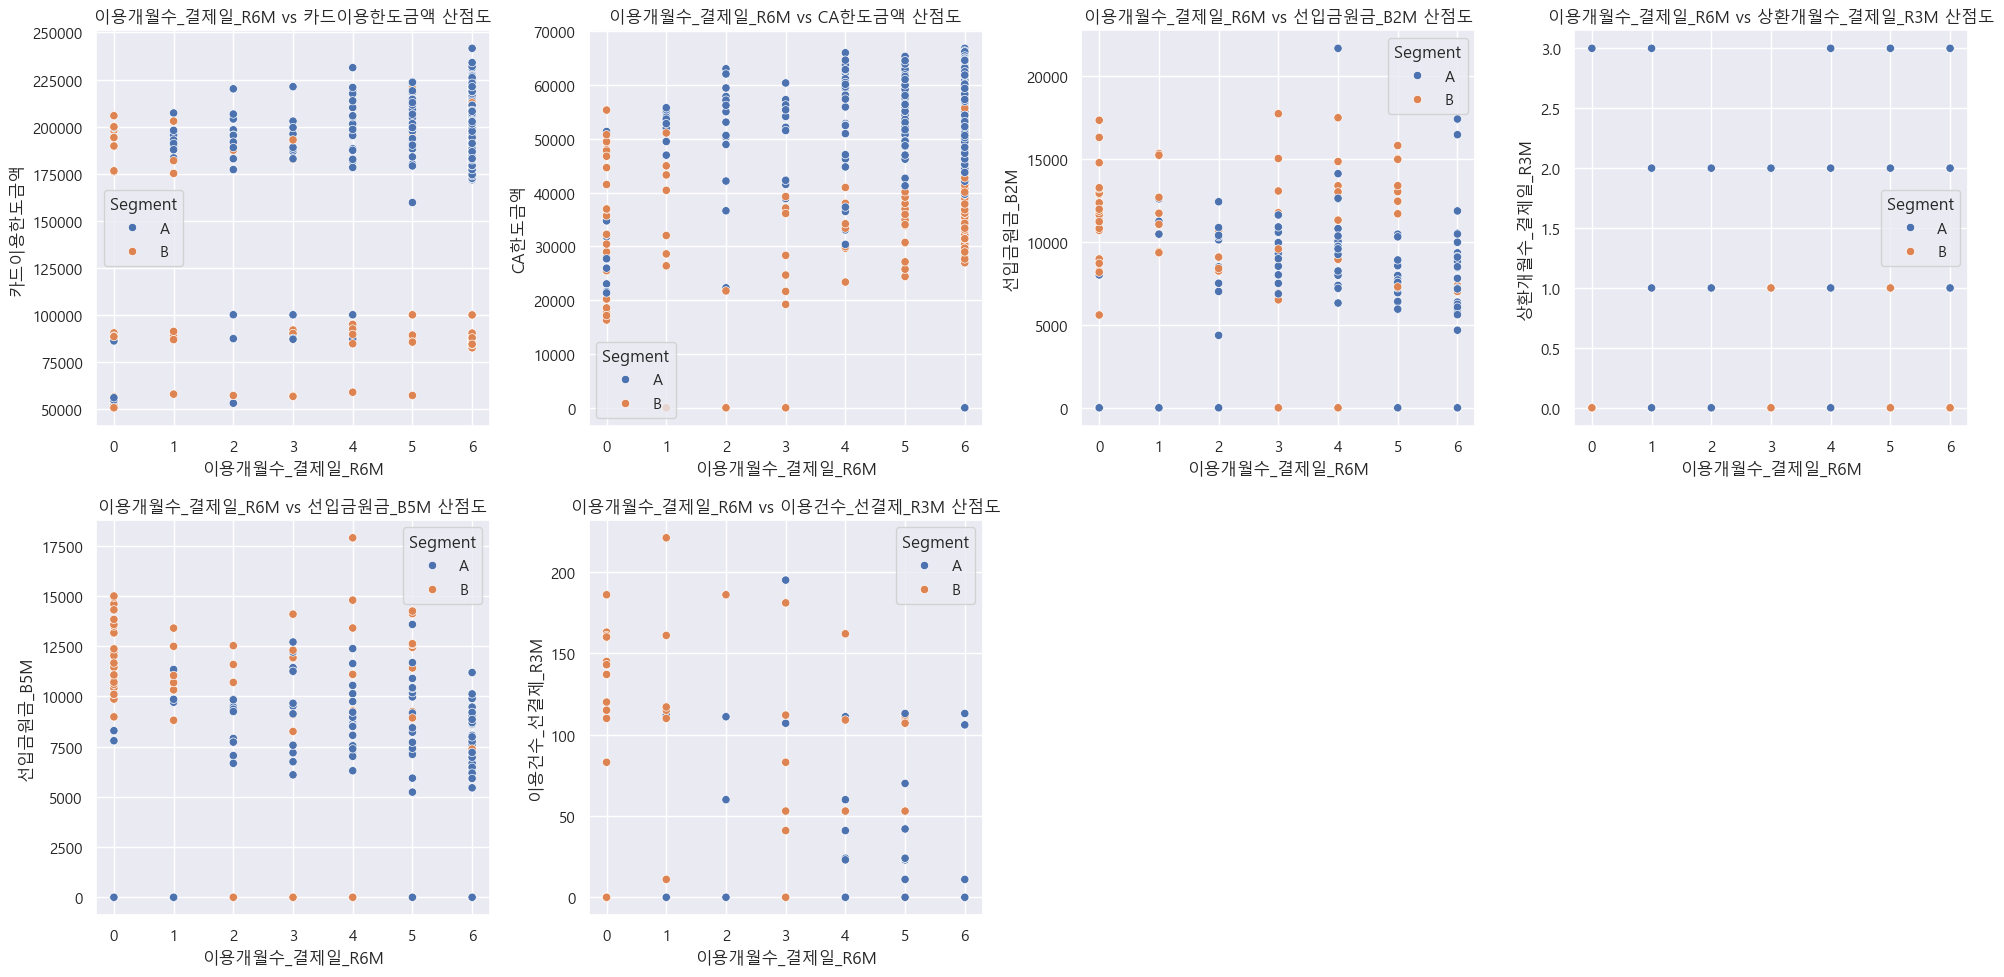

In [101]:
features = ['카드이용한도금액','CA한도금액', '선입금원금_B2M',
            '상환개월수_결제일_R3M', '선입금원금_B5M','이용건수_선결제_R3M' ]

plt.figure(figsize=(20, 10))

for i, f in enumerate(features):
    plt.subplot(2, 4, i+1)
    sns.scatterplot(data=df, x='이용개월수_결제일_R6M', y=f, hue='Segment')
    plt.title(f'이용개월수_결제일_R6M vs {f} 산점도')

plt.subplot(2, 4, 7+1).axis('off')

plt.tight_layout()
plt.show()

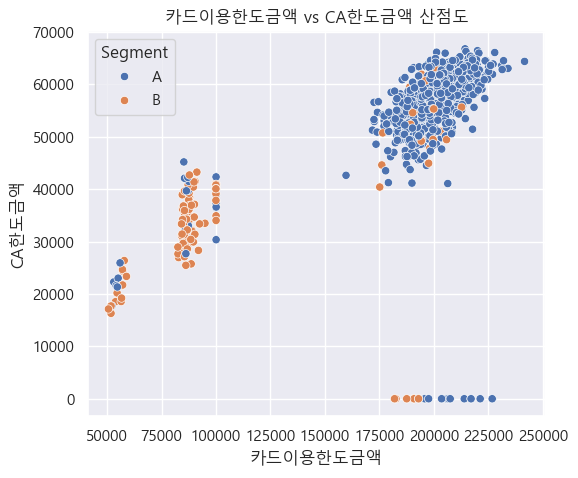

In [106]:
plt.figure(figsize=(6, 5))
sns.scatterplot(data=df, x='카드이용한도금액', y='CA한도금액', hue='Segment')
plt.title('카드이용한도금액 vs CA한도금액 산점도')
plt.xlabel('카드이용한도금액')
plt.ylabel('CA한도금액')
plt.tight_layout()
plt.show()

In [47]:
grouped_mean = df.groupby('Segment')[features].mean().T
grouped_median = df.groupby('Segment')[features].median().T

summary_df = pd.concat([grouped_mean, grouped_median], axis=1)
summary_df.columns = ['Mean_A', 'Mean_B', 'Median_A', 'Median_B']

summary_df = summary_df.round(3)

summary_df

,Mean_A,Mean_B,Median_A,Median_B
카드이용한도금액,197598.832,126400.125,200656.5,90212.0
CA한도금액,56036.476,38753.715,57666.5,36932.0
이용건수_선결제_R3M,2.103,31.319,0.0,0.0
선입금원금_B2M,854.887,4861.840,0.0,0.0
상환개월수_결제일_R3M,2.634,1.653,3.0,2.0
선입금원금_B5M,882.416,4599.917,0.0,0.0
이용개월수_결제일_R6M,5.638,4.188,6.0,6.0
